# Assignment 1 — EDA and Monte Carlo
## Pennsylvania County Income and Community Outreach Planning
**OPIM 5641 · Business Decision Modeling**

This notebook explores county income differences and asks a planning question: **If 30 outreach events independently select Pennsylvania counties with equal probability, what is the probability that the average county per capita income across their locations is below $25,000?**

The workflow follows M1.1 (load, clean, summarize, visualize, enrich) and M1.2 (random draws, a loop, and probability interpretation). The data and planning scenario differ from the classroom examples. All code and narrative are included here. Run cells from top to bottom in Google Colab.

The dollar threshold is a hypothetical teaching benchmark in the historical data's dollars, not an official eligibility rule. The modeled uncertainty is **which counties host events**, not future income growth or the earnings of individual attendees.

[Open in Colab](https://colab.research.google.com/github/chong-guo/opim5641-work/blob/main/Assignment_1/Assignment_1_PA_Income_MC.ipynb)

**Step 1: Scrape the table from Wikipedia**

In [1]:
import pandas as pd               # tables
import requests                   # fetching web pages politely
import io                         # wrapping text so read_html can parse it
import matplotlib.pyplot as plt

In [2]:
url = 'https://en.wikipedia.org/wiki/List_of_Pennsylvania_counties_by_per_capita_income'

In [3]:
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0 (OPIM 5641 teaching demo)'})
print(response.status_code)

200


In [4]:
# parse ALL the tables on the page from the HTML we already downloaded
tables = pd.read_html(io.StringIO(response.text))

# how many tables did we get? which one is ours?
for i, t in enumerate(tables):
    print(i, t.shape)

0 (6, 1)
1 (70, 7)
2 (5, 2)
3 (9, 2)


In [5]:
# grab the county summary table
df = tables[1]
df

,Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,*,United States,"$27,334","$51,914","$62,982",308745538.0,116716292.0
1,*,Pennsylvania,"$27,049","$50,398","$63,364",12702379.0,5018904.0
2,1,Chester,"$41,251","$84,741","$94,592",498886.0,307750.0
3,2,Montgomery,"$40,076","$76,380","$94,592",799874.0,NaN
4,3,Bucks,"$35,687","$74,828","$90,274",625249.0,234849.0
...,...,...,...,...,...,...,...
65,64,Clinton,"$19,261","$39,354","$50,055",39238.0,15151.0
66,65,Fayette,"$19,209","$34,796","$44,114",136606.0,55997.0
67,66,Mifflin,"$19,085","$37,539","$46,598",46682.0,18743.0
68,67,Forest,"$14,325","$35,150","$43,750",7716.0,2511.0


**Step 2: Clean the scrape**

In [6]:
phantom = df['County'].isin(['Pennsylvania', 'United States']) | df['County'].isna()
df.style.apply(lambda row: ['background-color: #FFC7CE' if phantom[row.name] else '' for _ in row], axis=1)

,Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,*,United States,"$27,334","$51,914","$62,982",308745538.000000,116716292.000000
1,*,Pennsylvania,"$27,049","$50,398","$63,364",12702379.000000,5018904.000000
2,1,Chester,"$41,251","$84,741","$94,592",498886.000000,307750.000000
3,2,Montgomery,"$40,076","$76,380","$94,592",799874.000000,nan
4,3,Bucks,"$35,687","$74,828","$90,274",625249.000000,234849.000000
5,4,Delaware,"$32,067","$61,876","$77,879",558979.000000,208700.000000
6,5,Cumberland,"$30,119","$60,219","$75,000",235406.000000,93943.000000
7,6,Allegheny,"$29,549","$47,961","$65,678",1223348.000000,533960.000000
8,7,Butler,"$28,446","$56,878","$69,464",183862.000000,72835.000000
9,8,Northampton,"$28,362","$58,762","$70,457",297735.000000,113565.000000


In [7]:
df['Population'].describe()

,Population
count,6.900000e+01
mean,4.842758e+06
std,3.715510e+07
min,5.085000e+03
25%,4.494700e+04
50%,9.110800e+04
75%,2.354060e+05
max,3.087455e+08


In [8]:
# the fix: drop the blank row, then drop the state and national rows by name
df = df.dropna(subset=['County'])
df = df[~df['County'].isin(['Pennsylvania', 'United States'])]
print(len(df), 'real county rows now')

# AFTER: counties only
df

67 real county rows now


,Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
2,1,Chester,"$41,251","$84,741","$94,592",498886.0,307750.0
3,2,Montgomery,"$40,076","$76,380","$94,592",799874.0,NaN
4,3,Bucks,"$35,687","$74,828","$90,274",625249.0,234849.0
5,4,Delaware,"$32,067","$61,876","$77,879",558979.0,208700.0
6,5,Cumberland,"$30,119","$60,219","$75,000",235406.0,93943.0
...,...,...,...,...,...,...,...
64,63,Sullivan,"$19,718","$36,250","$48,168",6428.0,2777.0
65,64,Clinton,"$19,261","$39,354","$50,055",39238.0,15151.0
66,65,Fayette,"$19,209","$34,796","$44,114",136606.0,55997.0
67,66,Mifflin,"$19,085","$37,539","$46,598",46682.0,18743.0


In [9]:
# sanity restored - the max Population is Middlesex again, not the entire USA
df['Population'].describe()

,Population
count,6.700000e+01
mean,1.895877e+05
std,2.683390e+05
min,5.085000e+03
25%,4.419850e+04
50%,8.888000e+04
75%,2.111285e+05
max,1.526006e+06


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67 entries, 2 to 68
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     67 non-null     object 
 1   County                   67 non-null     object 
 2   Per capita income        67 non-null     object 
 3   Median household income  67 non-null     object 
 4   Median family income     67 non-null     object 
 5   Population               67 non-null     float64
 6   Number of households     66 non-null     float64
dtypes: float64(2), object(5)
memory usage: 4.2+ KB


In [12]:
# clean the three income columns: strip $ and , then convert to numeric
money_cols = ['Per capita income', 'Median household income', 'Median family income']

for col in money_cols:
    df[col] = (df[col]
               .astype(str)
               .str.replace('$', '', regex=False)   # drop dollar signs
               .str.replace(',', '', regex=False))  # drop thousands commas
    df[col] = pd.to_numeric(df[col], errors='coerce')

# how many NaNs did coercion create? (check your work!)
df[money_cols].isna().sum()

,0
Per capita income,0
Median household income,0
Median family income,0


**Step 3: Describe the data**

In [13]:
# the classic first look
df[money_cols + ['Population']].describe()

,Per capita income,Median household income,Median family income,Population
count,67.000000,67.000000,67.000000,6.700000e+01
mean,23645.552239,46663.611940,57272.955224,1.895877e+05
std,4602.587238,9685.550924,10932.574939,2.683390e+05
min,14325.000000,34796.000000,43750.000000,5.085000e+03
25%,20635.000000,40237.000000,50027.500000,4.419850e+04
50%,22173.000000,43595.000000,53083.000000,8.888000e+04
75%,25565.500000,51695.500000,63336.000000,2.111285e+05
max,41251.000000,84741.000000,94592.000000,1.526006e+06


In [14]:
df.sort_values('Per capita income', ascending=False)[['County', 'Per capita income', 'Median household income', 'Population']]

,County,Per capita income,Median household income,Population
2,Chester,41251,84741,498886.0
3,Montgomery,40076,76380,799874.0
4,Bucks,35687,74828,625249.0
5,Delaware,32067,61876,558979.0
6,Cumberland,30119,60219,235406.0
...,...,...,...,...
64,Sullivan,19718,36250,6428.0
65,Clinton,19261,39354,39238.0
66,Fayette,19209,34796,136606.0
67,Mifflin,19085,37539,46682.0


**Step 4: Visualize**

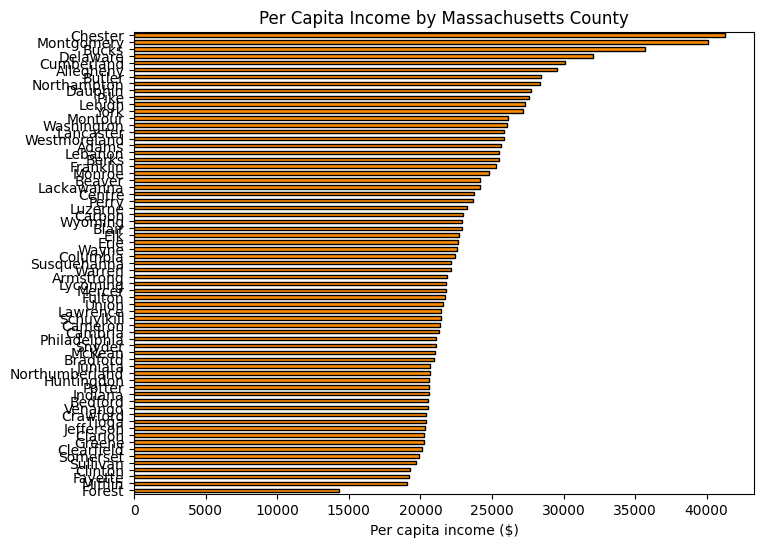

In [15]:
# per capita income by county, sorted - richest at the top
df.sort_values('Per capita income').plot(kind='barh', x='County', y='Per capita income', color='darkorange', edgecolor='black', legend=False, figsize=(8,6))
plt.title('Per Capita Income by Pennsylvania County')
plt.xlabel('Per capita income ($)')
plt.ylabel('')
plt.show()

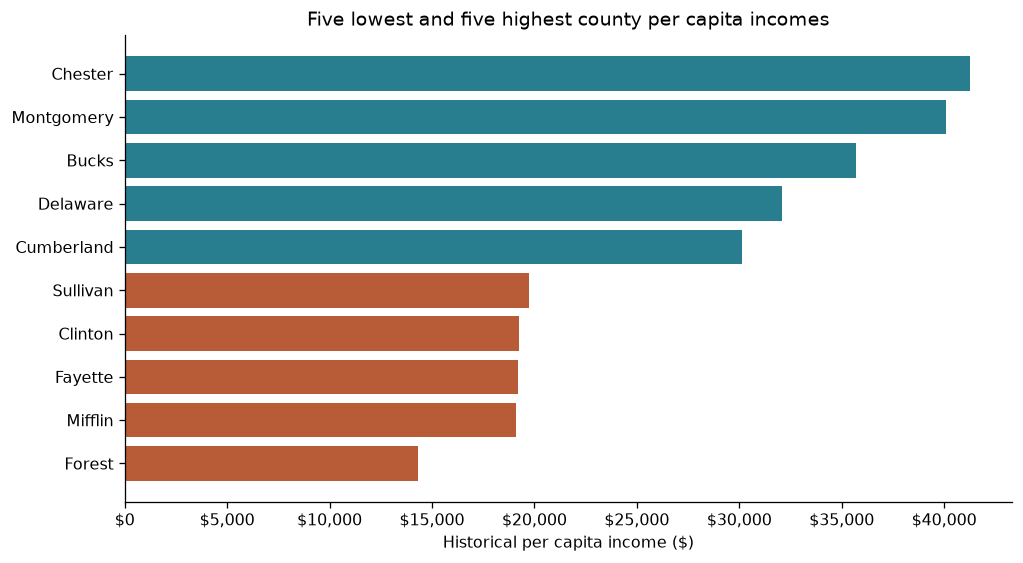

In [ ]:
ranked=income.sort_values('Per capita income')
selected=pd.concat([ranked.head(5),ranked.tail(5)])
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(selected['County'],selected['Per capita income'],color=['#b85c38']*5+['#287d8e']*5)
ax.set(title='Five lowest and five highest county per capita incomes',xlabel='Historical per capita income ($)')
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout();plt.show()

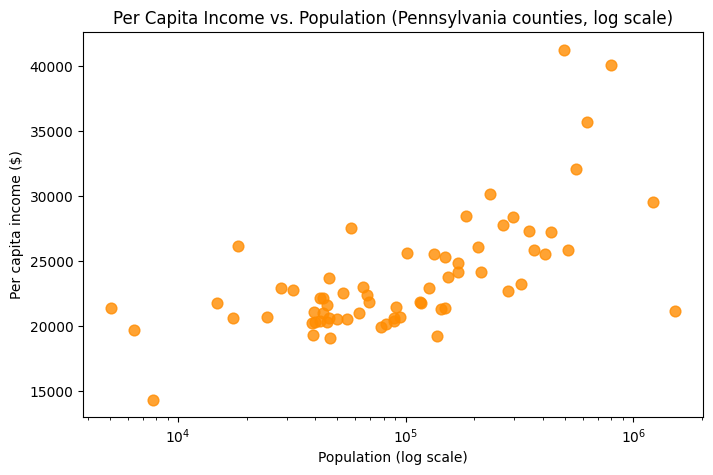

In [17]:
df.plot(kind='scatter', x='Population', y='Per capita income', alpha=0.8, s=60, color='darkorange', figsize=(8,5))
plt.xscale('log')
plt.title('Per Capita Income vs. Population (Pennsylvania counties, log scale)')
plt.xlabel('Population (log scale)')
plt.ylabel('Per capita income ($)')
plt.show()

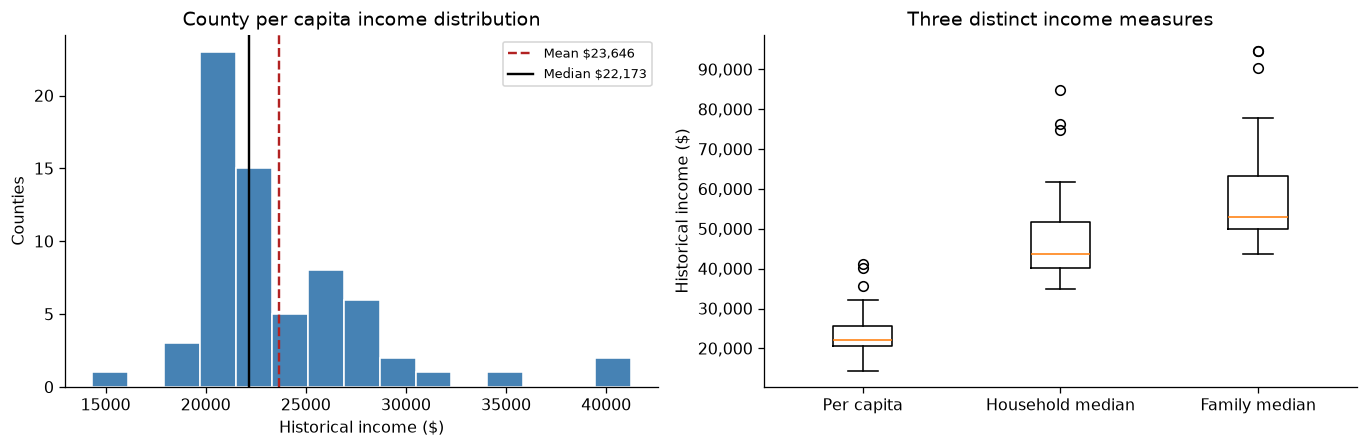

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(pci,bins=15,color='steelblue',edgecolor='white')
axes[0].axvline(pci.mean(),color='firebrick',linestyle='--',label=f'Mean ${pci.mean():,.0f}')
axes[0].axvline(pci.median(),color='black',label=f'Median ${pci.median():,.0f}')
axes[0].set(title='County per capita income distribution',xlabel='Historical income ($)',ylabel='Counties')
axes[0].legend(fontsize=8)
axes[1].boxplot([income[c] for c in money_cols],tick_labels=['Per capita','Household median','Family median'])
axes[1].set(title='Three distinct income measures',ylabel='Historical income ($)')
for ax in axes: ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout();plt.show()

The per capita distribution has a right tail: a few high-income counties lift its mean above its median. The household and family measures are higher partly because they measure different economic units, not because the same residents suddenly earn more. The boxplot compares distributions of county summaries, not individual household distributions.

This ranking identifies the tails while keeping labels readable. Chester, Montgomery, and Bucks are among the high-income counties in this snapshot. A county's position does not establish why its income differs; geography, employment, demographics, and measurement can all matter.

**Step5: Map it - counties as a choropleth**

In [18]:
# geopandas reads shapefiles straight from a URL - this is the Census Bureau's county map
import geopandas as gpd

counties = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_500k.zip')

# EDA the shapefile like any other table - it IS a table, just with a geometry column
print(counties.shape)   # ~3,200 rows: every county in the country
counties.head()

(3235, 13)


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,01,069,00161560,0500000US01069,01069,Houston,Houston County,AL,Alabama,06,1501742235,4795415,"POLYGON ((-85.71209 31.19727, -85.70934 31.198..."
1,01,023,00161537,0500000US01023,01023,Choctaw,Choctaw County,AL,Alabama,06,2365900083,19114321,"POLYGON ((-88.47323 31.89386, -88.46888 31.930..."
2,01,005,00161528,0500000US01005,01005,Barbour,Barbour County,AL,Alabama,06,2292160151,50523213,"POLYGON ((-85.74803 31.61918, -85.74544 31.618..."
3,01,107,00161580,0500000US01107,01107,Pickens,Pickens County,AL,Alabama,06,2282835044,22621093,"POLYGON ((-88.34043 32.9912, -88.33101 33.0724..."
4,01,033,00161542,0500000US01033,01033,Colbert,Colbert County,AL,Alabama,06,1535742270,79160396,"POLYGON ((-88.13925 34.5878, -88.13872 34.5892..."


In [19]:
counties['STATE_NAME'].unique()

array(['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Delaware', 'Florida', 'Illinois', 'Georgia', 'Idaho', 'Michigan',
       'Indiana', 'Iowa', 'New York', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Alaska', 'Maryland', 'Massachusetts', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'New Jersey',
       'New Mexico', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma',
       'Oregon', 'Pennsylvania', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'West Virginia', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Wisconsin', 'Wyoming', 'American Samoa',
       'Commonwealth of the Northern Mariana Islands', 'Puerto Rico',
       'Connecticut', 'Rhode Island', 'Nevada', 'New Hampshire', 'Hawaii',
       'United States Virgin Islands', 'Guam', 'District of Columbia'],
      dtype=object)

In [20]:
ma = counties[counties['STATEFP'] == '42']                       # by FIPS code (42 = Massachusetts)
ma_by_name = counties[counties['STATE_NAME'] == 'Pennsylvania'] # by state name

print(len(ma), "rows by STATEFP == '42'")
print(len(ma_by_name), "rows by STATE_NAME == 'Pennsylvania'")

67 rows by STATEFP == '42'
67 rows by STATE_NAME == 'Pennsylvania'


In [21]:
ma['NAME'].unique()

array(['Delaware', 'Erie', 'Greene', 'Lancaster', 'Dauphin', 'Juniata',
       'Centre', 'Clinton', 'Indiana', 'Perry', 'Fayette', 'Franklin',
       'Clarion', 'Huntingdon', 'York', 'Northampton', 'Wayne', 'Chester',
       'Montgomery', 'Blair', 'Clearfield', 'Sullivan', 'Somerset',
       'Philadelphia', 'Washington', 'Bucks', 'Northumberland', 'Cameron',
       'Pike', 'Monroe', 'Westmoreland', 'Allegheny', 'Armstrong',
       'Union', 'Lehigh', 'Columbia', 'Susquehanna', 'Lawrence',
       'Bedford', 'Mercer', 'McKean', 'Bradford', 'Warren', 'Tioga',
       'Potter', 'Berks', 'Mifflin', 'Forest', 'Montour', 'Schuylkill',
       'Jefferson', 'Elk', 'Lackawanna', 'Cumberland', 'Beaver', 'Fulton',
       'Crawford', 'Luzerne', 'Lycoming', 'Lebanon', 'Butler', 'Cambria',
       'Venango', 'Snyder', 'Adams', 'Carbon', 'Wyoming'], dtype=object)

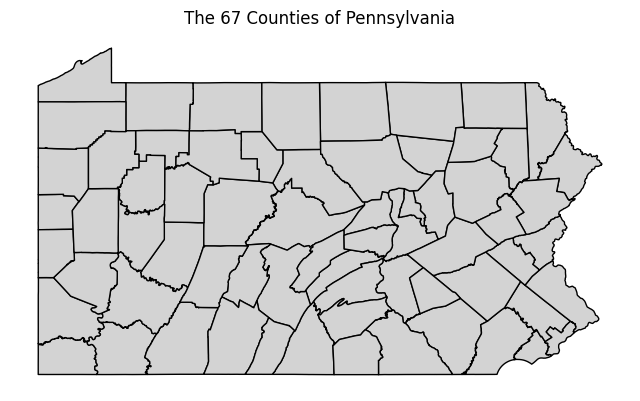

In [23]:
ma.plot(edgecolor='black', color='lightgray', figsize=(8,5))
plt.title('The 67 Counties of Pennsylvania')
plt.axis('off')
plt.show()

In [24]:
ma_map = ma.merge(df, left_on='NAME', right_on='County', how='left')
ma_map[['NAME'] + money_cols]

,NAME,Per capita income,Median household income,Median family income
0,Delaware,32067,61876,77879
1,Erie,22644,43595,56144
2,Greene,20258,40498,49488
3,Lancaster,25854,54765,64672
4,Dauphin,27727,52371,66023
...,...,...,...,...
62,Venango,20522,39812,48866
63,Snyder,21072,44713,51715
64,Adams,25606,56529,66222
65,Carbon,22956,47744,54918


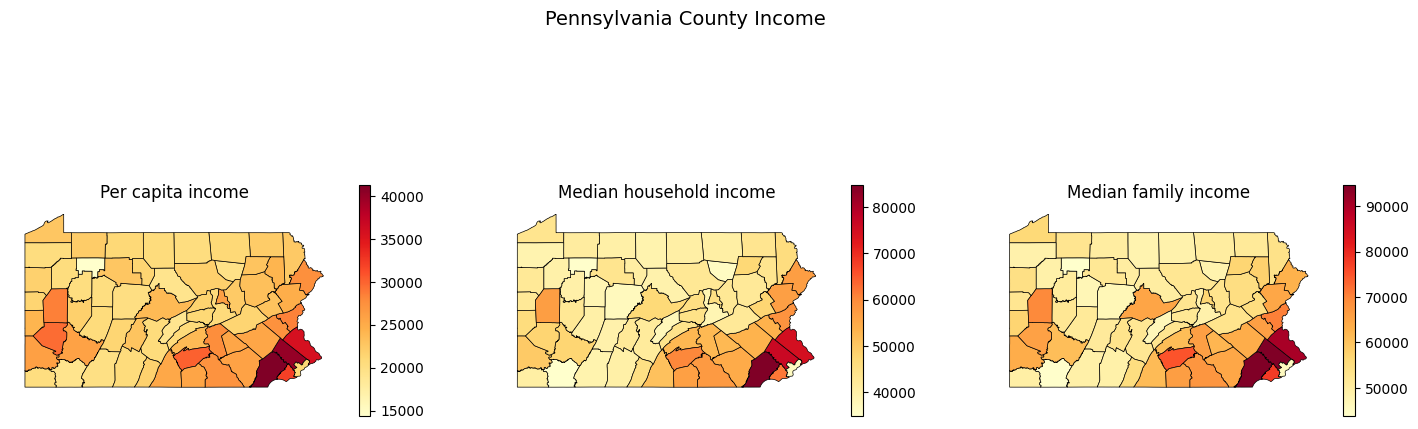

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, money_cols):
    ma_map.plot(column=col, cmap='YlOrRd', legend=True, edgecolor='black', linewidth=0.5, ax=ax,
                legend_kwds={'shrink': 0.5},
                missing_kwds={'color': 'lightgray', 'hatch': '///', 'label': 'no data'})
    ax.set_title(col)
    ax.axis('off')
plt.suptitle('Pennsylvania County Income', fontsize=14)
plt.show()

## **B. Monte Carlo model and assumptions**
Imagine a hypothetical program scheduling **30 events**. Each event independently selects one of the 67 counties with equal probability; repeat counties are permitted. The event inherits its location's historical county per capita income as a **context indicator**, not attendees' personal income.

For one simulated schedule, draw 30 values **with replacement** and calculate their arithmetic mean. Repeat for **10,000 schedules**. The question is:

**P(mean location county per capita income < $25,000).**

Using empirical resampling preserves the observed right tail without imposing a normal distribution. Equal county weights are a policy assumption, not population weights. Independence and repeat locations simplify logistics. This is a prospective scheduling scenario evaluated against a fixed historical baseline, not a forecast of future income. Income-estimate sampling error is not modeled.

In [ ]:
income_values=enriched['Per capita income'].to_numpy(dtype=float)
n_events=30
n_trials=10000
threshold=25000.0
seed=5641
rng=np.random.default_rng(seed)  # set once, outside the loop

# One example schedule shows exactly what is aggregated.
example_rng=np.random.default_rng(seed)
example_values=example_rng.choice(income_values,size=n_events,replace=True)
print('Example schedule mean:',round(example_values.mean(),2))

results=[]
for trial in range(n_trials):
    event_incomes=rng.choice(income_values,size=n_events,replace=True)
    results.append(event_incomes.mean())
results=np.array(results)
assert len(results)==10000 and np.isfinite(results).all()
assert results.min()>=income_values.min() and results.max()<=income_values.max()

Example schedule mean: 22625.9


## 7. Results and probability interpretation
The histogram summarizes uncertainty across schedules. The 5th–95th percentile range contains approximately 90% of modeled schedule averages; it is not a confidence interval for the true statewide income.

,Estimate
Mean ($),"23,649.5948"
Median ($),"23,604.6500"
5th percentile ($),"22,340.1400"
95th percentile ($),"25,121.9600"
"P(mean < $25,000)",0.9373
Monte Carlo SE of probability,0.0024


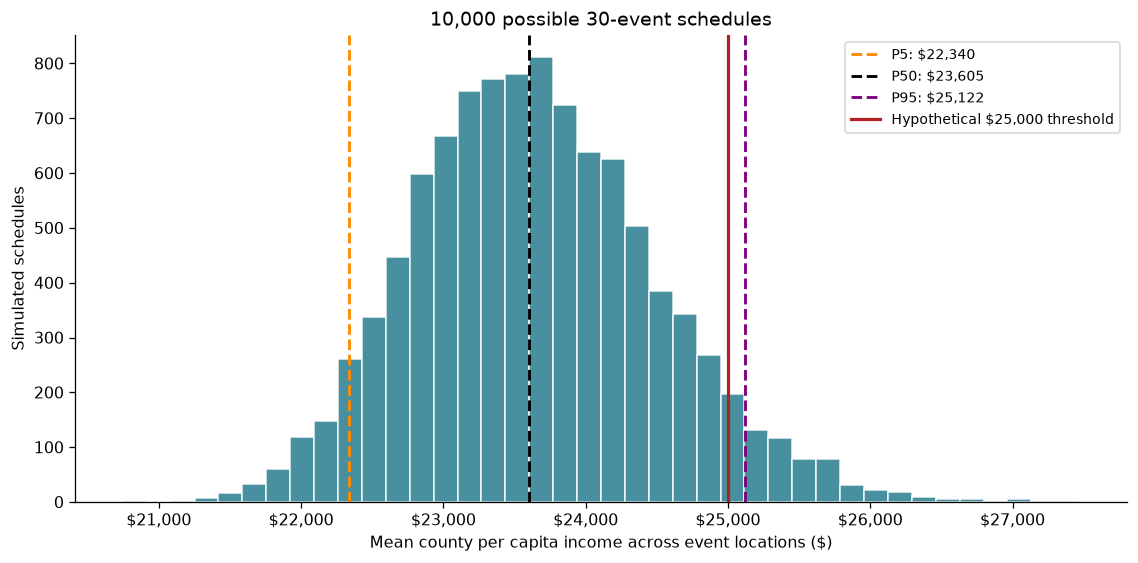

**Answer:** 9,373 of 10,000 simulated schedules fall below the threshold, giving an estimated probability of **93.73%**. The simulated mean is **$23,650**, and approximately 90% of schedule averages lie between **$22,340 and $25,122**. The Monte Carlo standard error of the probability is **0.24 percentage points**, reflecting simulation noise only.

In [ ]:
p5,p50,p95=np.percentile(results,[5,50,95])
probability=np.mean(results<threshold)
mc_se=np.sqrt(probability*(1-probability)/n_trials)
summary=pd.Series({'Mean ($)':results.mean(),'Median ($)':p50,'5th percentile ($)':p5,
    '95th percentile ($)':p95,'P(mean < $25,000)':probability,'Monte Carlo SE of probability':mc_se})
display(summary.to_frame('Estimate').style.format({'Estimate':'{:,.4f}'}))
fig,ax=plt.subplots(figsize=(10,5))
ax.hist(results,bins=40,color='#287d8e',edgecolor='white',alpha=.85)
for q,value,color in zip([5,50,95],[p5,p50,p95],['darkorange','black','purple']):
    ax.axvline(value,color=color,linestyle='--',linewidth=1.8,label=f'P{q}: ${value:,.0f}')
ax.axvline(threshold,color='firebrick',linewidth=2,label='Hypothetical $25,000 threshold')
ax.set(title='10,000 possible 30-event schedules',xlabel='Mean county per capita income across event locations ($)',ylabel='Simulated schedules')
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend(fontsize=9);plt.tight_layout();plt.show()
display(Markdown(f"**Answer:** {np.count_nonzero(results<threshold):,} of {n_trials:,} simulated schedules fall below "
    f"the threshold, giving an estimated probability of **{probability:.2%}**. "
    f"The simulated mean is **${results.mean():,.0f}**, and approximately 90% of schedule averages lie "
    f"between **${p5:,.0f} and ${p95:,.0f}**. The Monte Carlo standard error of the probability is "
    f"**{100*mc_se:.2f} percentage points**, reflecting simulation noise only."))

## 8. Validation and sensitivity
For independent draws with replacement, the exact expected schedule average equals the mean of the empirical county distribution. Its standard deviation equals that distribution's standard deviation divided by the square root of 30. This gives a useful mathematical check. A separate seed-reset check confirms reproducibility.

In [ ]:
expected_mean=income_values.mean()
expected_sd=income_values.std(ddof=0)/np.sqrt(n_events)
display(pd.DataFrame({'Quantity':['Mean','SD of schedule average'],
    'Analytical':[expected_mean,expected_sd], 'Simulated':[results.mean(),results.std(ddof=1)]}))
assert abs(results.mean()-expected_mean)<5*expected_sd/np.sqrt(n_trials)
check_rng=np.random.default_rng(seed)
repeated=np.array([check_rng.choice(income_values,n_events,replace=True).mean() for _ in range(n_trials)])
assert np.array_equal(results,repeated)
assert 0<=probability<=1
display(pd.DataFrame({'Hypothetical threshold ($)':[23000,24000,25000,26000],
    'Probability below threshold':[np.mean(results<t) for t in [23000,24000,25000,26000]]}).style.format({'Probability below threshold':'{:.2%}'}))
print('Validation passed: 67 unique matched counties, 10,000 finite outcomes, reproducible draws.')

,Quantity,Analytical,Simulated
0,Mean,"23,645.55","23,649.59"
1,SD of schedule average,834.02,850.93


,Hypothetical threshold ($),Probability below threshold
0,23000,22.89%
1,24000,67.59%
2,25000,93.73%
3,26000,99.38%


Validation passed: 67 unique matched counties, 10,000 finite outcomes, reproducible draws.


The sensitivity table shows that the probability depends on the chosen policy benchmark. It is not a universal statement about Pennsylvania. These checks validate the implementation under its assumptions; they do not validate the assumptions themselves.

## 9. Conclusion and limitations
The EDA documents substantial variation across county income summaries. Geographic enrichment supplies an independent coverage check and shows how income relates descriptively to land area and county location. The simulation turns this observed variation into a probability about **a 30-event schedule**, instead of reporting only an average.

The probability above can help compare a hypothetical schedule-selection policy with an income-context benchmark. It cannot show how many low-income people an event reaches. A real program would need current, verified socioeconomic data, participant information, travel constraints, and an explicit equitable allocation policy before making decisions.

Limitations include historical data, possible Wikipedia errors, different geographic/income vintages, equal county selection rather than population weighting, independent events, repeated counties, and no measurement-error model. Lower simulated income averages do not demonstrate program impact or causality.

**Attribution:** workflow adapted from Dr. Dave Wanik's OPIM 5641 M1.1 and M1.2 notebooks. This draft was prepared with AI assistance for code, explanations, and validation; the student should review the work and be able to explain the assumptions and each step. The separate handwritten math check is not included here.